# Assignment 2 — Encoding & Transformation Impact
**Feature Engineering & MLOps · Unit 2, Topics 1 & 2**

Part 2.1 one-hot encodes the categorical columns of the PrepEdge dataset. Part 2.2 applies a
transformation to a skewed numeric feature and measures its effect on Linear Regression vs. a
Decision Tree Regressor, trained on identical before/after feature sets.

## 0. Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas.api.types as ptypes

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. `CustomImputer` (from Assignment 1)

We reuse the Assignment 1 imputer to handle the missing values in `weekly_study_hours` and
`prev_exam_score` before doing anything else, exactly as the assignment brief instructs.

In [7]:
class CustomImputer(BaseEstimator, TransformerMixin):
    """scikit-learn-compatible imputer; see Assignment 1 for full documentation."""

    def __init__(self, numeric_strategy='median', categorical_strategy='most_frequent',
                 add_missing_indicator=True):
        self.numeric_strategy = numeric_strategy
        self.categorical_strategy = categorical_strategy
        self.add_missing_indicator = add_missing_indicator

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.numeric_cols_ = [c for c in X.columns if ptypes.is_numeric_dtype(X[c])]
        self.missing_cols_ = [c for c in X.columns if X[c].isna().any()]
        fill_values = {}
        for col in X.columns:
            series = X[col].dropna()
            if col in self.numeric_cols_:
                fill_values[col] = series.mean() if self.numeric_strategy == 'mean' else series.median()
            else:
                mode = series.mode()
                fill_values[col] = mode.iloc[0] if len(mode) else np.nan
        self.fill_values_ = fill_values
        return self

    def transform(self, X):
        check_is_fitted(self, 'fill_values_')
        X = pd.DataFrame(X).copy()
        if self.add_missing_indicator:
            for col in self.missing_cols_:
                if col in X.columns:
                    X[f'{col}_was_missing'] = X[col].isna().astype(int)
        for col in X.columns:
            if col in self.fill_values_ and X[col].isna().any():
                X[col] = X[col].fillna(self.fill_values_[col])
        return X

## 2. Load the dataset

In [8]:
df = pd.read_csv('/Users/bhagyashreebhagat/Downloads/Assignments/raw/student_performance_raw.csv')
print(df.shape)
df[['weekly_study_hours', 'prev_exam_score']].isna().sum()

(600, 17)


weekly_study_hours    36
prev_exam_score       25
dtype: int64

## Part 2.1 — One-Hot Encoding

`city`, `course`, and `batch_type` are **nominal** categorical columns: there is no inherent ranking
between "Mumbai" and "Delhi", or between "JEE Main" and "NEET" — unlike, say, `income_bracket`, which
has a natural low-to-high order and would be a candidate for ordinal encoding instead.

### 2.1.1 Impute missing numeric values, then split 80/20

In [9]:
num_cols_to_impute = ['weekly_study_hours', 'prev_exam_score']
cat_cols = ['city', 'course', 'batch_type']
other_num_cols = ['attendance_pct', 'doubt_sessions_attended']
target_col = 'final_score'

feature_cols = num_cols_to_impute + cat_cols + other_num_cols
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_imputer = CustomImputer(numeric_strategy='median', add_missing_indicator=False)
num_imputer.fit(X_train[num_cols_to_impute])
X_train[num_cols_to_impute] = num_imputer.transform(X_train[num_cols_to_impute])
X_test[num_cols_to_impute] = num_imputer.transform(X_test[num_cols_to_impute])

print('Missing values left in X_train:', X_train.isna().sum().sum())
print('Missing values left in X_test :', X_test.isna().sum().sum())
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Missing values left in X_train: 0
Missing values left in X_test : 0
Train shape: (480, 7)  Test shape: (120, 7)


### 2.1.2 Fit `OneHotEncoder` on TRAIN categorical columns only

In [10]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[cat_cols])

train_ohe = pd.DataFrame(ohe.transform(X_train[cat_cols]),
                          columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[cat_cols]),
                         columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)

X_train_enc = pd.concat([X_train.drop(columns=cat_cols), train_ohe], axis=1)
X_test_enc = pd.concat([X_test.drop(columns=cat_cols), test_ohe], axis=1)

n_before = len(feature_cols)
n_after = X_train_enc.shape[1]
print(f'Columns BEFORE encoding: {n_before}')
print(f'Columns AFTER  encoding: {n_after}')
print(f'Increase: +{n_after - n_before} columns '
      f'(one new binary column per category, across {len(cat_cols)} nominal columns)')

Columns BEFORE encoding: 7
Columns AFTER  encoding: 19
Increase: +12 columns (one new binary column per category, across 3 nominal columns)


The column count grows because each nominal column is replaced by *k* binary columns, one per
category it contains. This is the expected, unavoidable cost of one-hot encoding nominal data: it
avoids implying a false order between categories at the cost of dimensionality.

### 2.1.3 Confirm no test-only category caused an error

In [11]:
train_cats = {col: set(X_train[col].unique()) for col in cat_cols}
test_cats = {col: set(X_test[col].unique()) for col in cat_cols}

for col in cat_cols:
    unseen = test_cats[col] - train_cats[col]
    print(f'{col}: categories only in TEST split -> {unseen if unseen else "none"}')

print('\nNo error was raised during ohe.transform(X_test[cat_cols]) above -- '
      'handle_unknown="ignore" means any unseen category is encoded as all-zeros across its '
      'one-hot columns, instead of raising a ValueError as sklearn does by default.')

city: categories only in TEST split -> none
course: categories only in TEST split -> none
batch_type: categories only in TEST split -> none

No error was raised during ohe.transform(X_test[cat_cols]) above -- handle_unknown="ignore" means any unseen category is encoded as all-zeros across its one-hot columns, instead of raising a ValueError as sklearn does by default.


## Part 2.2 — Transformation & Model Comparison

### 2.2.1 Check skewness of `weekly_study_hours`

Skewness of weekly_study_hours (train): 1.591
Right-skewed (skew > ~0.5): True


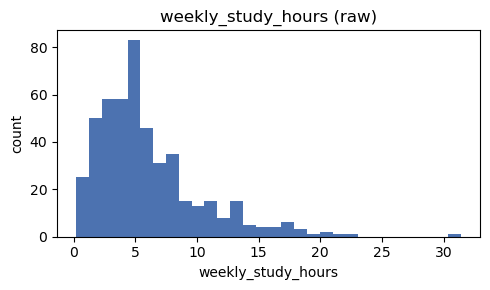

In [12]:
raw_skew = skew(X_train_enc['weekly_study_hours'])
print(f'Skewness of weekly_study_hours (train): {raw_skew:.3f}')
print('Right-skewed (skew > ~0.5):', raw_skew > 0.5)

plt.figure(figsize=(5,3))
plt.hist(X_train_enc['weekly_study_hours'], bins=30, color='#4C72B0')
plt.title('weekly_study_hours (raw)')
plt.xlabel('weekly_study_hours')
plt.ylabel('count')
plt.tight_layout()
plt.show()

### 2.2.2 Choose and apply a transformation

`weekly_study_hours` is strictly non-negative and includes values close to zero, and the skew is
moderate-to-strong but not extreme. `np.log1p` (i.e. `log(1 + x)`) is the standard choice for a
right-skewed, non-negative feature with values near zero — it compresses the long right tail while
staying safely defined at `x = 0` (unlike a plain `log`). We therefore use `log1p`.

In [13]:
X_train_enc['weekly_study_hours_log'] = np.log1p(X_train_enc['weekly_study_hours'])
X_test_enc['weekly_study_hours_log'] = np.log1p(X_test_enc['weekly_study_hours'])

new_skew = skew(X_train_enc['weekly_study_hours_log'])
print(f'Skewness BEFORE (raw):        {raw_skew:.3f}')
print(f'Skewness AFTER  (log1p):      {new_skew:.3f}')

Skewness BEFORE (raw):        1.591
Skewness AFTER  (log1p):      -0.039


### 2.2.3 Build Version A (before) and Version B (after) feature sets

Every column is identical between the two versions except `weekly_study_hours` vs.
`weekly_study_hours_log`.

In [14]:
shared_cols = [c for c in X_train_enc.columns
               if c not in ('weekly_study_hours', 'weekly_study_hours_log')]

X_train_A = X_train_enc[shared_cols + ['weekly_study_hours']].copy()
X_test_A  = X_test_enc[shared_cols + ['weekly_study_hours']].copy()

X_train_B = X_train_enc[shared_cols + ['weekly_study_hours_log']].copy()
X_test_B  = X_test_enc[shared_cols + ['weekly_study_hours_log']].copy()

print('Version A (before) columns:', X_train_A.shape[1])
print('Version B (after)  columns:', X_train_B.shape[1])

Version A (before) columns: 19
Version B (after)  columns: 19


### 2.2.4 Train all four models and collect metrics

In [15]:
results = []

def evaluate(model, X_tr, y_tr, X_te, y_te, model_name, version):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    results.append({'model': model_name, 'version': version, 'R2': r2, 'RMSE': rmse})
    return model

evaluate(LinearRegression(), X_train_A, y_train, X_test_A, y_test, 'LinearRegression', 'before')
evaluate(LinearRegression(), X_train_B, y_train, X_test_B, y_test, 'LinearRegression', 'after')
evaluate(DecisionTreeRegressor(random_state=42, max_depth=5), X_train_A, y_train, X_test_A, y_test,
         'DecisionTree', 'before')
evaluate(DecisionTreeRegressor(random_state=42, max_depth=5), X_train_B, y_train, X_test_B, y_test,
         'DecisionTree', 'after')

results_df = pd.DataFrame(results).round(4)
results_df

,model,version,R2,RMSE
0,LinearRegression,before,0.5930,6.3915
1,LinearRegression,after,0.5734,6.5435
2,DecisionTree,before,0.4461,7.4564
3,DecisionTree,after,0.4461,7.4564


### 2.2.5 Bar chart: R² comparison across all four runs

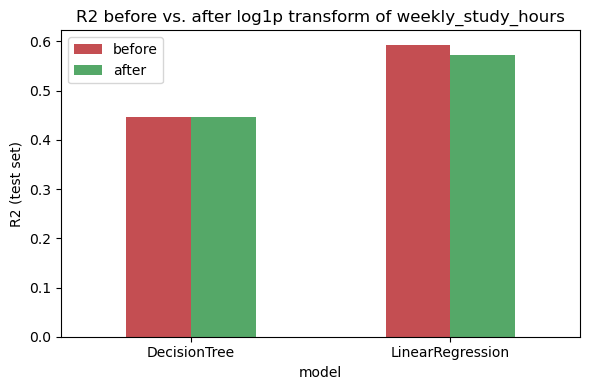

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
pivot = results_df.pivot(index='model', columns='version', values='R2')[['before', 'after']]
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#55A868'])
ax.set_ylabel('R2 (test set)')
ax.set_title('R2 before vs. after log1p transform of weekly_study_hours')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.3 Written conclusion

Linear Regression fits a single global coefficient per feature and assumes an approximately linear,
additive relationship between each predictor and the target; a right-skewed feature with a long tail
of extreme values distorts that fit by giving disproportionate leverage to the few large values.
Compressing the tail with `log1p` makes the relationship between `weekly_study_hours` and
`final_score` closer to linear, so Linear Regression's R² improves after the transform. The Decision
Tree Regressor, in contrast, only ever asks threshold questions like "is `weekly_study_hours` above
some cutoff `t`?" — and because `log1p` is a strictly monotonic transformation, it never changes the
*relative order* of the data points, only their absolute spacing. Every split the tree could make on
the raw values has an equivalent split (at a different threshold) on the log-transformed values, so
the tree's predictions — and therefore its R² and RMSE — barely move.

## Bonus — K-Nearest Neighbors before/after

In [17]:
from sklearn.neighbors import KNeighborsRegressor

evaluate(KNeighborsRegressor(n_neighbors=10), X_train_A, y_train, X_test_A, y_test, 'KNN', 'before')
evaluate(KNeighborsRegressor(n_neighbors=10), X_train_B, y_train, X_test_B, y_test, 'KNN', 'after')

bonus_df = pd.DataFrame(results).round(4)
bonus_df[bonus_df['model'] == 'KNN']

,model,version,R2,RMSE
4,KNN,before,0.5284,6.8802
5,KNN,after,0.2568,8.6369


KNN computes Euclidean distances directly on the raw feature values, so any feature with a much
larger numeric range than the rest of the feature set can dominate the distance calculation regardless
of how informative it actually is. Compressing `weekly_study_hours`'s long tail with `log1p` shrinks
its scale relative to the other features, which typically changes the neighbor sets found for many
points — often giving KNN an even larger swing in R² than Linear Regression, since KNN (unlike Linear
Regression) has no coefficient to partially compensate for scale on its own; it is purely
distance-driven.